In [25]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('Cleaned_Data_Analytics_Dataset.csv')

In [27]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,1/4/2023 0:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,8/23/2024 0:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2/27/2024 0:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,10/15/2023 0:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,5/8/2025 0:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Exploratory Data Analysis

In [28]:
# Prepare the data for analysis
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Year'] = df['Date'].dt.year

numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
display(df[numeric_cols].isna().sum().to_frame('Missing Values'))

Rows: 1200
Columns: 16


,Missing Values
Quantity,0
UnitPrice,0
ItemsInCart,0
TotalPrice,0


## Basic Statistics

In [29]:
basic_statistics = df[numeric_cols].agg(['count', 'mean', 'median']).T.round(2)
basic_statistics

,count,mean,median
Quantity,1200.0,2.95,3.00
UnitPrice,1200.0,356.41,364.21
ItemsInCart,1200.0,5.48,5.00
TotalPrice,1200.0,1053.97,823.62


## Distributions

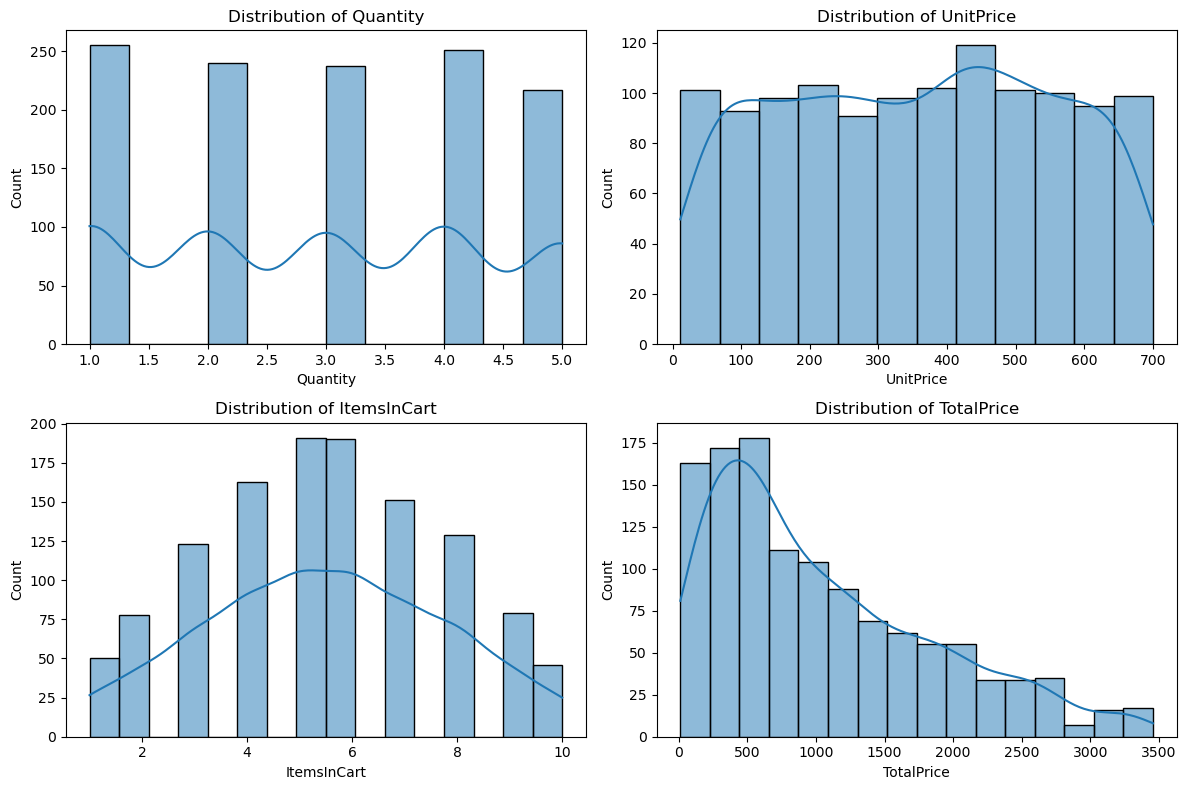

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

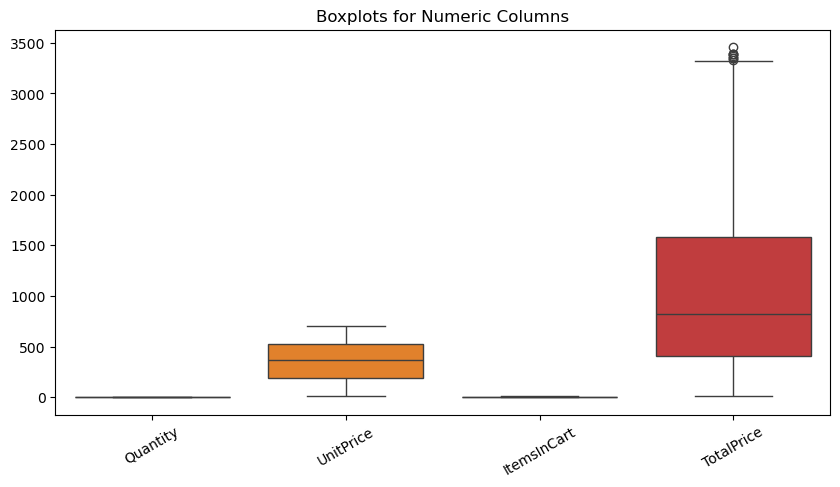

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplots for Numeric Columns')
plt.xticks(rotation=30)
plt.show()

## Trends and Patterns

,Month,Orders,TotalRevenue,AverageOrderValue
25,2025-02,37,35317.55,954.528378
26,2025-03,49,39200.66,800.013469
27,2025-04,32,31821.20,994.412500
28,2025-05,37,43396.64,1172.882162
29,2025-06,49,53047.40,1082.600000


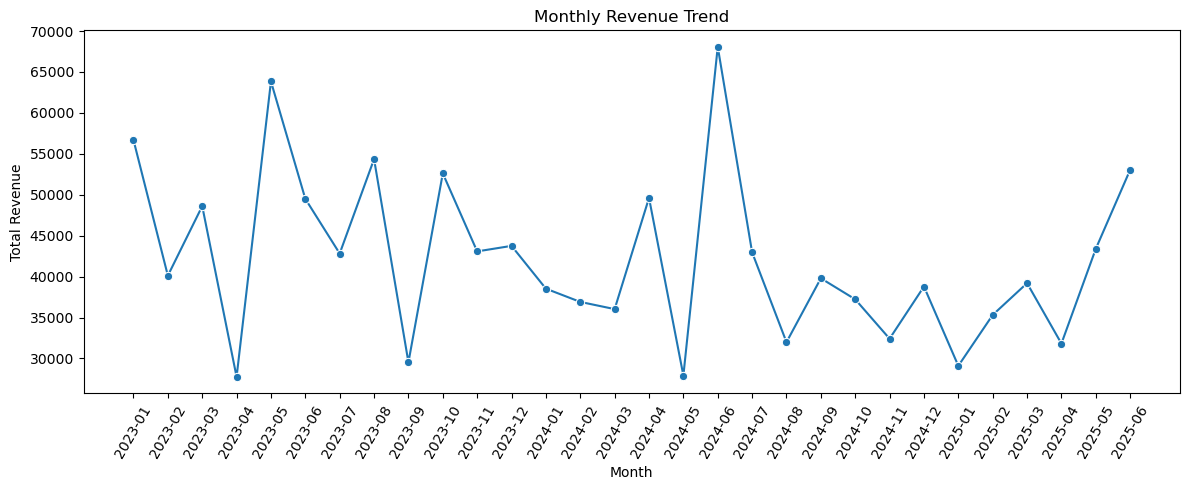

In [32]:
monthly_trends = (
    df.groupby('Month')
      .agg(Orders=('OrderID', 'count'), TotalRevenue=('TotalPrice', 'sum'), AverageOrderValue=('TotalPrice', 'mean'))
      .reset_index()
)

display(monthly_trends.tail())

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_trends, x='Month', y='TotalRevenue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

,Orders,TotalRevenue,AverageOrderValue
Product,,,
Chair,178,195620.11,1098.99
Printer,181,195612.61,1080.73
Laptop,173,192126.56,1110.56
Tablet,179,186568.95,1042.28
Monitor,163,175651.41,1077.62
Desk,170,167459.93,985.06
Phone,156,151722.39,972.58


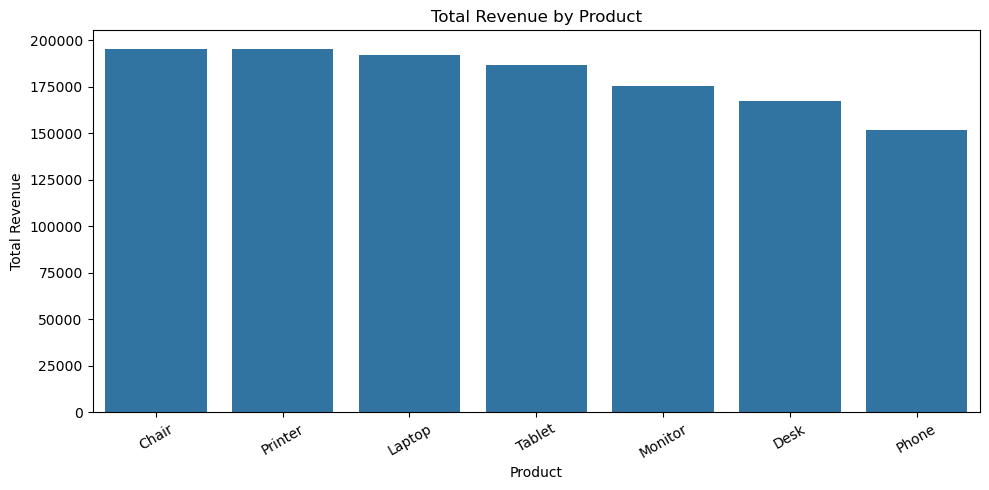

In [33]:
product_summary = (
    df.groupby('Product')
      .agg(Orders=('OrderID', 'count'), TotalRevenue=('TotalPrice', 'sum'), AverageOrderValue=('TotalPrice', 'mean'))
      .sort_values('TotalRevenue', ascending=False)
      .round(2)
)

display(product_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=product_summary.reset_index(), x='Product', y='TotalRevenue')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [34]:
status_counts = df['OrderStatus'].value_counts().to_frame('Count')
payment_counts = df['PaymentMethod'].value_counts().to_frame('Count')
referral_summary = (
    df.groupby('ReferralSource')
      .agg(Orders=('OrderID', 'count'), TotalRevenue=('TotalPrice', 'sum'), AverageOrderValue=('TotalPrice', 'mean'))
      .sort_values('TotalRevenue', ascending=False)
      .round(2)
)

display(status_counts)
display(payment_counts)
display(referral_summary)

,Count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


,Count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


,Orders,TotalRevenue,AverageOrderValue
ReferralSource,,,
Instagram,259,275285.45,1062.88
Email,250,261808.55,1047.23
Google,241,250441.48,1039.18
Facebook,228,250410.90,1098.29
Referral,222,226815.58,1021.69


## Outlier Detection

In [35]:
outlier_results = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_results.append([col, q1, q3, lower_bound, upper_bound, outlier_count])

outlier_summary = pd.DataFrame(
    outlier_results,
    columns=['Column', 'Q1', 'Q3', 'Lower Bound', 'Upper Bound', 'Outlier Count']
).round(2)

outlier_summary

,Column,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,Quantity,2.00,4.00,-1.00,7.00,0
1,UnitPrice,186.06,521.57,-317.20,1024.83,0
2,ItemsInCart,4.00,7.00,-0.50,11.50,0
3,TotalPrice,410.52,1578.48,-1341.41,3330.41,8


### Outlier Graphs

These graphs make the outliers easier to see visually. The dashed lines show the IQR lower and upper bounds.

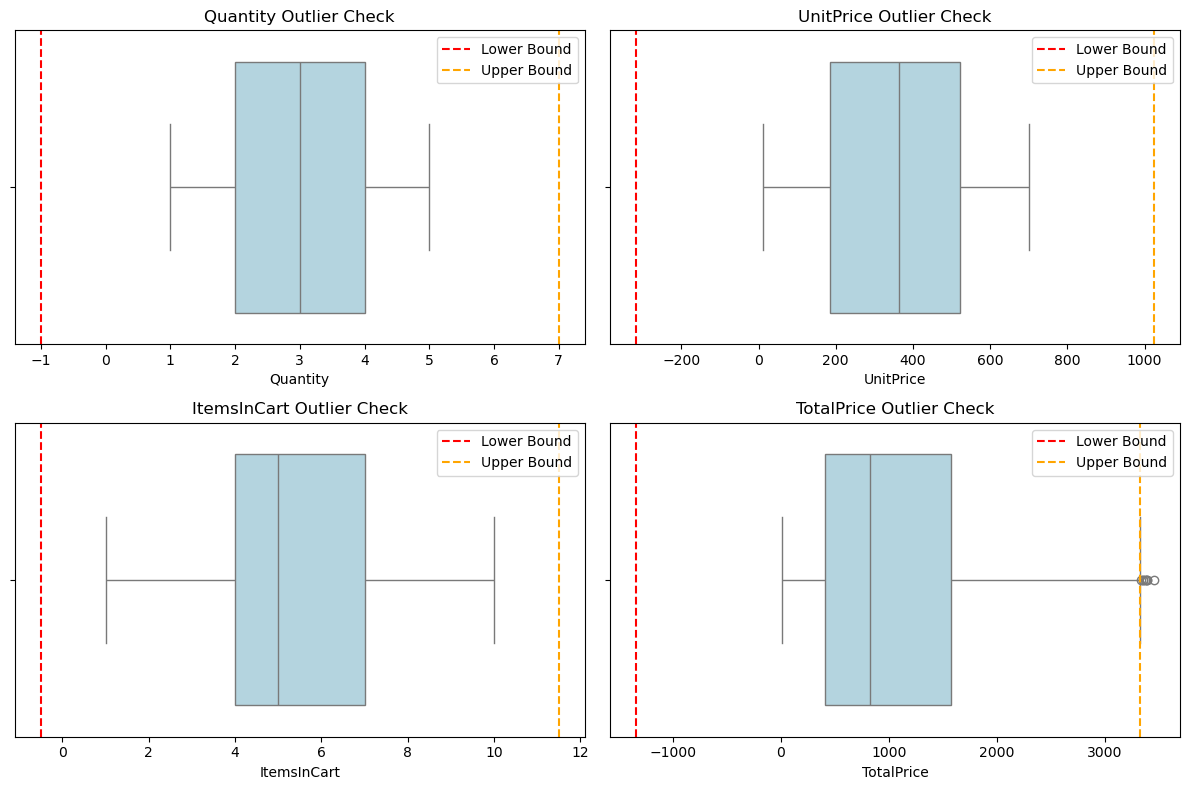

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    sns.boxplot(x=df[col], ax=ax, color='lightblue')
    ax.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
    ax.axvline(upper_bound, color='orange', linestyle='--', label='Upper Bound')
    ax.set_title(f'{col} Outlier Check')
    ax.legend()

plt.tight_layout()
plt.show()

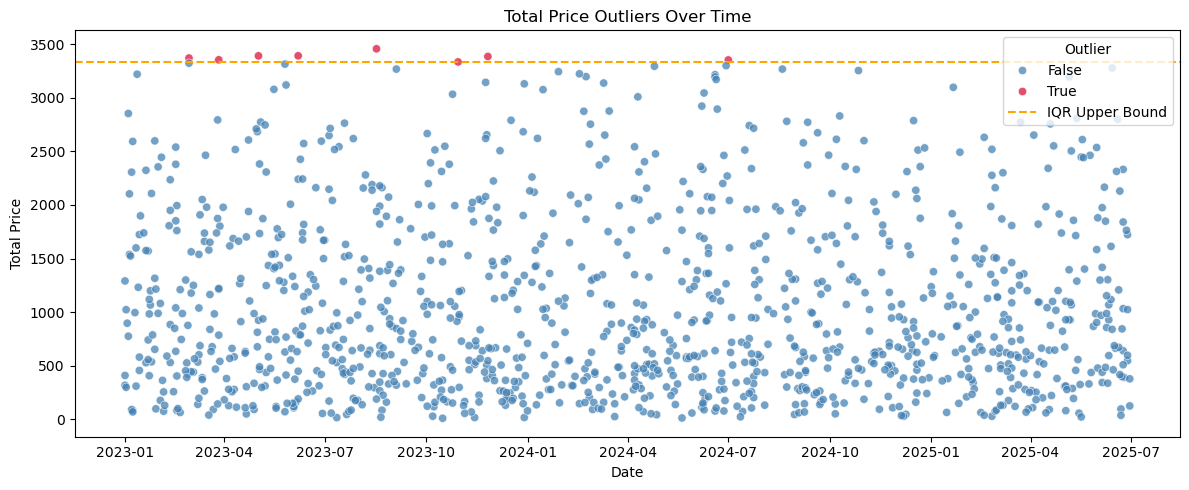

In [37]:
total_price_q1 = df['TotalPrice'].quantile(0.25)
total_price_q3 = df['TotalPrice'].quantile(0.75)
total_price_iqr = total_price_q3 - total_price_q1
total_price_upper = total_price_q3 + 1.5 * total_price_iqr

df['TotalPriceOutlier'] = df['TotalPrice'] > total_price_upper

plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=df,
    x='Date',
    y='TotalPrice',
    hue='TotalPriceOutlier',
    palette={False: 'steelblue', True: 'crimson'},
    alpha=0.75
)
plt.axhline(total_price_upper, color='orange', linestyle='--', label='IQR Upper Bound')
plt.title('Total Price Outliers Over Time')
plt.xlabel('Date')
plt.ylabel('Total Price')
plt.legend(title='Outlier')
plt.tight_layout()
plt.show()

In [38]:
total_price_q1 = df['TotalPrice'].quantile(0.25)
total_price_q3 = df['TotalPrice'].quantile(0.75)
total_price_iqr = total_price_q3 - total_price_q1
total_price_upper = total_price_q3 + 1.5 * total_price_iqr

total_price_outliers = (
    df[df['TotalPrice'] > total_price_upper]
      .sort_values('TotalPrice', ascending=False)
      [['OrderID', 'Date', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']]
)

total_price_outliers

,OrderID,Date,Product,Quantity,UnitPrice,TotalPrice
789,ORD200789,2023-08-17,Tablet,5,691.28,3456.40
1122,ORD201122,2023-06-07,Monitor,5,678.19,3390.95
632,ORD200632,2023-05-02,Laptop,5,678.16,3390.80
469,ORD200469,2023-11-26,Chair,5,676.98,3384.90
328,ORD200328,2023-02-28,Tablet,5,674.04,3370.20
107,ORD200107,2023-03-27,Printer,5,670.75,3353.75
326,ORD200326,2024-07-01,Laptop,5,670.48,3352.40
1065,ORD201065,2023-10-30,Printer,5,666.80,3334.00


## Key Observations

- The dataset contains 1,200 orders. Average total order value is about 1,053.97, while the median is about 823.62, which means a smaller number of high-value orders raises the average.
- Quantity is tightly distributed from 1 to 5 items, with an average close to 3 items per order.
- TotalPrice has the clearest outliers. Using the IQR rule, 8 high-value orders are above the upper bound of about 3,328.85.
- Chair, Printer, and Laptop generate the highest total revenue among products, while Phone produces the lowest total revenue in this dataset.
- Monthly revenue changes over time instead of staying flat. The strongest revenue month in the dataset is June 2024.
- Order statuses are fairly balanced, but Cancelled and Returned orders are slightly more common than Delivered orders, which may be important for business performance analysis.
- Instagram and Email are the strongest referral sources by total revenue, suggesting they are important channels for customer acquisition.